# JPEG Dataset Exploration

This notebook explores the PPMR dataset used in the deep contrastive metric learning paper.

## Dataset structure

```
data/PPMR/
├── PMGstudycaseslabelled/       ← 24 PMG patients (IDs: 2,3,4,5,...,34)
│   └── {pt}/
│       └── {pt}cor_1/           ← coronal MRI slices, one JPEG per slice
│           └── {pt}cor_1_{slice}_{label}.jpg
│
└── PMGControlsEditedDec2021/    ← same 24 IDs, healthy-control age-matched scans
    └── {pt}/
        ├── {pt}control1/        ← {pt}control1_cor_0_{slice}.jpg
        ├── {pt}control2/
        └── {pt}control3/
```

## Slice label convention

| Label | Where | Meaning |
|---|---|---|
| `0` | Controls folder | Control / healthy brain slice |
| `1` | PMG folder | **PMG found** — this slice shows polymicrogyria |
| `2` | PMG folder | **No PMG visible** — the patient has PMG, but this particular slice looks normal |
| `3` | PMG folder | **Uncertain / excluded** — ambiguous annotation, removed from all analyses |

> **Note:** The binary classification task is therefore:  
> Positive class = label **1** (PMG visible)  
> Negative class = label **0** (controls) + label **2** (no PMG visible in PMG patient)

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from natsort import natsorted
from collections import Counter

# ── Paths
BASE        = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'data', 'PPMR_processed'))
PMG_DIR     = os.path.join(BASE, 'PMGcases')
CTRL_DIR    = os.path.join(BASE, 'controlcases')

print('PMG  dir:', PMG_DIR,  '→ exists:', os.path.isdir(PMG_DIR))
print('CTRL dir:', CTRL_DIR, '→ exists:', os.path.isdir(CTRL_DIR))

PMG  dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_processed/PMGcases → exists: True
CTRL dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_processed/controlcases → exists: True


---
## Data Overview

### Patient 22 is excluded
Patient 22's age-matched control scans are missing/corrupted in the **original** PPMR archive, making a properly paired comparison impossible. The patient's PMG folder data (scan + labels) exists in our processed copy, but the patient is excluded from all analyses to remain consistent with the original paper's methodology.

### Image resolution — a key confound

| Group | Typical resolution | Range |
|---|---|---|
| PMG cases | 1508 × 1727 px | All scans at this high resolution |
| Controls | 512 × 512 px (median) | 260 × 320 px → 512 × 512 px |

This **systematic resolution difference** is a potential confound: a trivial model could classify PMG vs. control based on image dimensions alone, without learning any pathological features.

---

### Three views of the dataset

| Table | Patients | Label=3 | Label=2 in... | Total |
|---|---|---|---|---|
| **A** — Raw archive | all 24 (incl. pt 22) | included | PMG folder | all slices |
| **B** — Article 2 approach | 23 (excl. pt 22) | treated as **normal** (negative) | negative class | ≈ 15,056 |
| **C** — Optimal approach | 23 (excl. pt 22) | **removed** entirely | merged into negative | ≈ 14,181 |

> **Rationale for Table C:** Label=3 slices are radiologically ambiguous — their annotation is uncertain by definition. Including them as either positive or negative introduces noise. Removing them yields a clean binary split: **positive = label 1** (PMG clearly visible), **negative = label 2 + all controls** (no PMG visible).

In [ ]:
# ── DATA OVERVIEW — three views of the dataset
# (self-contained: re-scans the processed folders directly)

# ─── 1. Scan all PMG slices and record per-patient label counts
_raw_pmg = []
for patient in natsorted(os.listdir(PMG_DIR)):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    for fname in os.listdir(os.path.join(pt_path, sub)):
        if not fname.lower().endswith('.jpg'):
            continue
        try:
            lbl = int(fname.split('.')[0].split('_')[3])
        except (IndexError, ValueError):
            continue
        _raw_pmg.append({'patient': int(patient), 'label': lbl})

# ─── 2. Scan all control slices
_raw_ctrl = []
for patient in natsorted(os.listdir(CTRL_DIR)):
    pt_path = os.path.join(CTRL_DIR, patient)
    for sub in os.listdir(pt_path):
        col = sub[len(patient):]
        n = len([f for f in os.listdir(os.path.join(pt_path, sub)) if f.lower().endswith('.jpg')])
        _raw_ctrl.append({'patient': int(patient), 'ctrl_group': col, 'n': n})

df_pmg_raw  = pd.DataFrame(_raw_pmg)
df_ctrl_raw = pd.DataFrame(_raw_ctrl)

# ─── 3. Build per-patient pivot tables
_pmg_pivot = (
    df_pmg_raw.groupby(['patient', 'label']).size().unstack(fill_value=0)
    .rename(columns={1: 'lbl_1 (PMG)', 2: 'lbl_2 (normal)', 3: 'lbl_3 (uncertain)'})
    .reset_index()
)
for c in ['lbl_1 (PMG)', 'lbl_2 (normal)', 'lbl_3 (uncertain)']:
    if c not in _pmg_pivot.columns:
        _pmg_pivot[c] = 0

_ctrl_pivot = (
    df_ctrl_raw.groupby(['patient', 'ctrl_group'])['n'].sum().unstack(fill_value=0)
    .reset_index()
)
for c in ['control1', 'control2', 'control3']:
    if c not in _ctrl_pivot.columns:
        _ctrl_pivot[c] = 0
_ctrl_pivot[['control1', 'control2', 'control3']] = \
    _ctrl_pivot[['control1', 'control2', 'control3']].astype(int)

df_ov = _pmg_pivot.merge(_ctrl_pivot, on='patient', how='outer').fillna(0)
for c in ['lbl_1 (PMG)', 'lbl_2 (normal)', 'lbl_3 (uncertain)', 'control1', 'control2', 'control3']:
    df_ov[c] = df_ov[c].astype(int)

df_ov['PMG folder'] = df_ov[['lbl_1 (PMG)', 'lbl_2 (normal)', 'lbl_3 (uncertain)']].sum(axis=1)
df_ov['Controls']   = df_ov[['control1', 'control2', 'control3']].sum(axis=1)
df_ov['Total']      = df_ov['PMG folder'] + df_ov['Controls']
df_ov['Status']     = df_ov['patient'].map({22: '⚠ excl. (art.2)'}).fillna('✓')
df_ov = df_ov.sort_values('patient').reset_index(drop=True)

# ════════════════════════════════════════════════════════════════════════════
# TABLE A — Complete raw dataset (all 24 patients, all labels)
# ════════════════════════════════════════════════════════════════════════════
_show = ['patient', 'lbl_1 (PMG)', 'lbl_2 (normal)', 'lbl_3 (uncertain)',
         'PMG folder', 'control1', 'control2', 'control3', 'Controls', 'Total', 'Status']
print('TABLE A — Complete raw dataset  (all 24 patients, all labels)')
print('─'*105)
print(df_ov[_show].rename(columns={'patient': 'Patient'}).to_string(index=False))
_t = df_ov[_show[1:-1]].sum()
print('─'*105)
print(f"  {'TOTAL':<8}", '  '.join(f'{int(_t[c]):>6}' for c in _show[1:-1]))
print(f"\n  Grand total: {int(df_ov['Total'].sum()):,} slices across all 24 patients\n")

# ════════════════════════════════════════════════════════════════════════════
# TABLE B — Article 2 approach  (Zheng et al., deep contrastive metric learning)
# Patient 22 excluded (no matched controls in original archive)
# label=3 treated as "normal" (negative class)
# ════════════════════════════════════════════════════════════════════════════
_art2     = df_ov[df_ov['patient'] != 22].copy()
_art2_pos = int(_art2['lbl_1 (PMG)'].sum())
_art2_neg = int(_art2[['lbl_2 (normal)', 'lbl_3 (uncertain)', 'Controls']].sum().sum())
_art2_tot = _art2_pos + _art2_neg

print('TABLE B — Article 2 approach  (Zheng et al.)')
print('  Patient 22 excluded (control data unusable in original archive)')
print('  label=3 (uncertain) treated as negative/normal alongside label=2 and controls')
print('─'*60)
_b = _art2[['patient', 'lbl_1 (PMG)']].copy()
_b['Negative (lbl2+lbl3+ctrl)'] = (_art2['lbl_2 (normal)']
                                    + _art2['lbl_3 (uncertain)']
                                    + _art2['Controls'])
_b['Total'] = _b['lbl_1 (PMG)'] + _b['Negative (lbl2+lbl3+ctrl)']
_b.columns  = ['Patient', 'Positive (label=1)', 'Negative (lbl2+lbl3+ctrl)', 'Total']
print(_b.to_string(index=False))
print('─'*60)
print(f"  {'TOTAL':<15}  {_art2_pos:>6}  {_art2_neg:>25}  {_art2_tot:>6}")
print(f"\n  Class imbalance: 1 : {_art2_neg/_art2_pos:.1f}  |  Total = {_art2_tot:,}  (paper cites ≈ 15,056)\n")

# ════════════════════════════════════════════════════════════════════════════
# TABLE C — Optimal approach  (~14,181 slices)
# ALL 24 patients included; label=3 removed; label=2 merged into negative class
# No age-matched pairing needed for binary classification — pt22 is included.
# ════════════════════════════════════════════════════════════════════════════
_opt     = df_ov.copy()                          # ← all 24 patients, no exclusion
_opt_pos = int(_opt['lbl_1 (PMG)'].sum())
_opt_neg = int(_opt[['lbl_2 (normal)', 'Controls']].sum().sum())
_opt_tot = _opt_pos + _opt_neg
_lbl3_removed = int(_opt['lbl_3 (uncertain)'].sum())

print('TABLE C — Optimal approach')
print('  All 24 patients included (patient 22 kept — no paired-matching needed for binary classification)')
print('  label=3 (uncertain) slices removed entirely')
print('  label=2 (no PMG visible in PMG patient) merged with healthy controls → single negative class')
print('─'*65)
_c = _opt[['patient', 'lbl_1 (PMG)']].copy()
_c['Negative (lbl2+ctrl)'] = _opt['lbl_2 (normal)'] + _opt['Controls']
_c['Total'] = _c['lbl_1 (PMG)'] + _c['Negative (lbl2+ctrl)']
_c.columns  = ['Patient', 'Positive (label=1)', 'Negative (lbl2+ctrl)', 'Total']
print(_c.to_string(index=False))
print('─'*65)
print(f"  {'TOTAL':<15}  {_opt_pos:>6}  {_opt_neg:>20}  {_opt_tot:>6}")
print(f"\n  Class imbalance: 1 : {_opt_neg/_opt_pos:.1f}  |  Total = {_opt_tot:,}  (paper cites ≈ 14,181)")
print(f"  label=3 slices removed: {_lbl3_removed:,}")

---
## 1  Image-size distribution

We load the width × height of every slice and group by:
- **PMG** (labelled cases)
- **control1 / control2 / control3** (healthy controls, three age-matched scans per patient)

In [11]:
records = []  # (width, height, group, patient_id)

# ── PMG cases 
for patient in tqdm(natsorted(os.listdir(PMG_DIR)), desc='PMG patients'):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    slice_dir = os.path.join(pt_path, sub)
    for fname in os.listdir(slice_dir):
        if not fname.lower().endswith('.jpg'):
            continue
        w, h = Image.open(os.path.join(slice_dir, fname)).size
        records.append({'width': w, 'height': h, 'group': 'PMG', 'patient': int(patient)})

# ── Controls 
for patient in tqdm(natsorted(os.listdir(CTRL_DIR)), desc='Control patients'):
    pt_path = os.path.join(CTRL_DIR, patient)
    for sub in sorted(os.listdir(pt_path)):
        group = sub[len(patient):]          # → 'control1', 'control2', 'control3'
        slice_dir = os.path.join(pt_path, sub)
        for fname in os.listdir(slice_dir):
            if not fname.lower().endswith('.jpg'):
                continue
            w, h = Image.open(os.path.join(slice_dir, fname)).size
            records.append({'width': w, 'height': h, 'group': group, 'patient': int(patient)})

df_sizes = pd.DataFrame(records)
print('Groups found:', sorted(df_sizes['group'].unique()))
print(df_sizes.groupby('group')[['width', 'height']].describe().round(0))

Control patients: 100%|██████████| 24/24 [00:01<00:00, 16.47it/s]

Groups found: ['PMG', 'control1', 'control2', 'control3']
           width                                                        \
           count    mean    std    min     25%     50%     75%     max   
group                                                                    
PMG       4520.0  1455.0  223.0  512.0  1508.0  1508.0  1508.0  1508.0   
control1  3498.0   409.0  121.0  208.0   260.0   512.0   512.0   512.0   
control2  3564.0   421.0  114.0  260.0   288.0   512.0   512.0   512.0   
control3  3480.0   421.0  118.0  260.0   260.0   512.0   512.0   512.0   

          height                                                        
           count    mean    std    min     25%     50%     75%     max  
group                                                                   
PMG       4520.0  1662.0  272.0  512.0  1727.0  1727.0  1727.0  1727.0  
control1  3498.0   426.0  100.0  256.0   320.0   512.0   512.0   512.0  
control2  3564.0   435.0   96.0  288.0   320.0   512.0   5

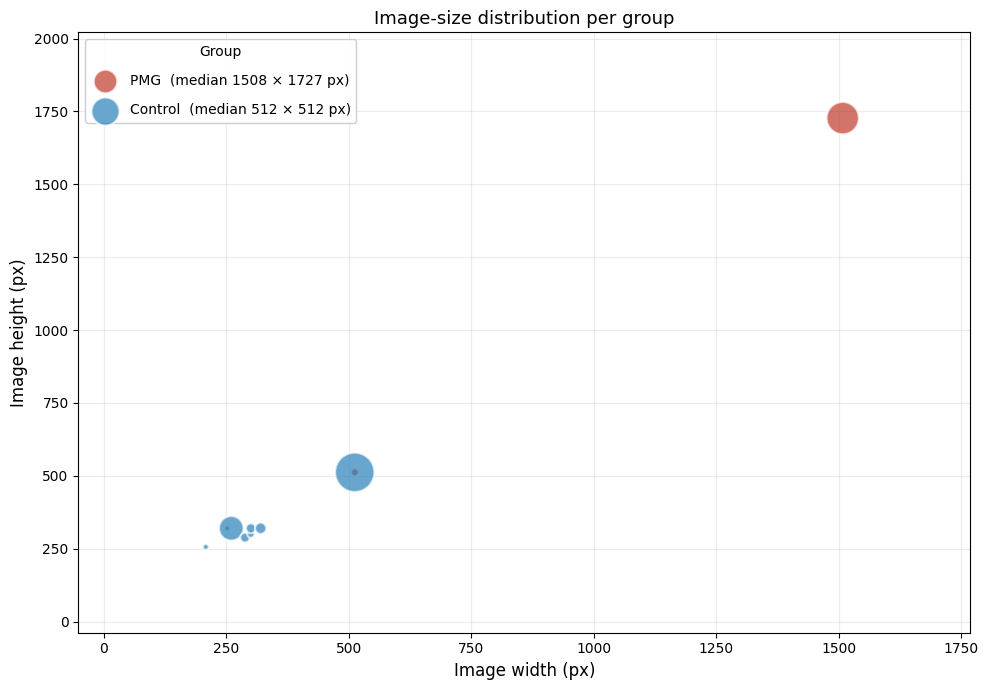

In [12]:
# Scatter plot — image-size distribution per group (linear scale)

# Merge control1/2/3 into a single 'Control' group
df_plot = df_sizes.copy()
df_plot['group'] = df_plot['group'].replace({'control1': 'Control', 'control2': 'Control', 'control3': 'Control'})

GROUP_COLORS = {
    'PMG':     '#C0392B',   # crimson
    'Control': '#2980B9',   # blue
}

# Compute median centroid per group for legend labels
centroids = df_plot.groupby('group')[['width', 'height']].median().astype(int)

# Aggregate to unique (group, width, height) -> count for bubble sizing
agg = (
    df_plot.groupby(['group', 'width', 'height'])
    .size().rename('n').reset_index()
)

MAX_BUBBLE  = 800
global_max  = agg['n'].max()

fig, ax = plt.subplots(figsize=(10, 7))

for group, color in GROUP_COLORS.items():
    sub = agg[agg['group'] == group]
    if sub.empty:
        continue
    cw, ch = centroids.loc[group, 'width'], centroids.loc[group, 'height']
    legend_label = f'{group}  (median {cw} × {ch} px)'
    sizes = (sub['n'] / global_max) * MAX_BUBBLE
    ax.scatter(
        sub['width'], sub['height'],
        s=sizes, c=color, alpha=0.70,
        edgecolors='white', linewidth=1.5,
        label=legend_label, zorder=3,
    )

ax.set_xlabel('Image width (px)', fontsize=12)
ax.set_ylabel('Image height (px)', fontsize=12)
ax.set_title('Image-size distribution per group', fontsize=13)
ax.legend(title='Group', fontsize=10, title_fontsize=10,
          framealpha=0.95, loc='upper left',
          scatterpoints=1, labelspacing=1.1)
ax.grid(True, alpha=0.25)
ax.margins(0.2)
plt.tight_layout()
plt.show()

---
## 2  Per-patient label distribution (PMG cases)

For each PMG patient we count slices by label:

| Label | Meaning |
|---|---|
| `1` | PMG found in this slice |
| `2` | No PMG visible (slice from PMG patient but looks normal) |

Label-3 (uncertain) slices are **excluded from all analyses**.

In [13]:
label_records = []  # (patient, label)

for patient in natsorted(os.listdir(PMG_DIR)):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    slice_dir = os.path.join(pt_path, sub)
    for fname in os.listdir(slice_dir):
        if not fname.lower().endswith('default.jpg'):
            continue
        label = int(fname.split('.')[0].split('_')[-3])
        label_records.append({'patient': int(patient), 'label': label})

df_labels = pd.DataFrame(label_records)
print(df_labels.value_counts())

print(df_labels)
print(df_labels.groupby('label')['patient'].nunique())
# Drop uncertain slices (label=3)
df_labels = df_labels[df_labels['label'] != 3]

# label=1 -> PMG found, label=2 -> no PMG visible
df_pivot = (
    df_labels
    .groupby(['patient', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: 'PMG found (label=1)', 2: 'No PMG visible (label=2)'})
    .sort_index()
)
print(df_pivot)

patient  label
10       1        179
33       1        175
3        1        158
8        2        146
4        1        145
                 ... 
31       3         15
5        3         12
4        3         10
2        3          9
30       3          7
Name: count, Length: 71, dtype: int64
      patient  label
0           2      2
1           2      1
2           2      2
3           2      2
4           2      1
...       ...    ...
4512       34      3
4513       34      2
4514       34      2
4515       34      2
4516       34      2

[4517 rows x 2 columns]
label
1    24
2    23
3    24
Name: patient, dtype: int64
label    PMG found (label=1)  No PMG visible (label=2)
patient                                               
2                         35                        97
3                        158                        54
4                        145                        25
5                        133                        25
6                        122            

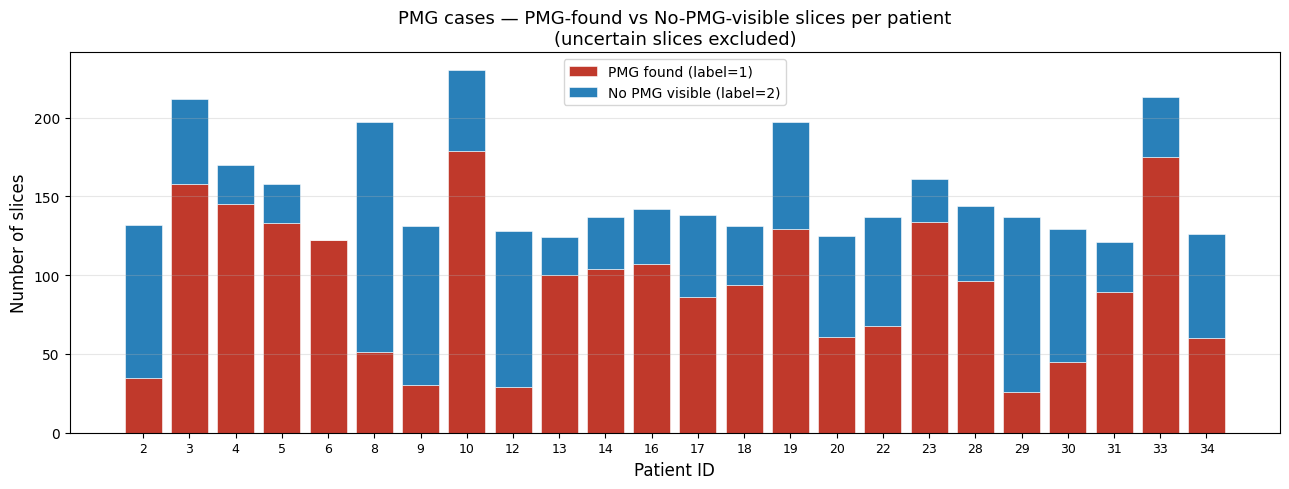

In [14]:
# ── Stacked bar - PMG cases only 
# label=1 (PMG found) -> crimson   |   label=2 (no PMG visible) -> blue
COL_COLORS = {
    'PMG found (label=1)':    '#C0392B',   # crimson — positive class
    'No PMG visible (label=2)': '#2980B9', # blue    — negative class
}

plot_cols = [c for c in COL_COLORS if c in df_pivot.columns]
patients = df_pivot.index.tolist()
x = np.arange(len(patients))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(patients))
for col in plot_cols:
    vals = df_pivot[col].values
    ax.bar(x, vals, bottom=bottom, label=col, color=COL_COLORS[col],
           edgecolor='white', linewidth=0.4)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in patients], fontsize=9)
ax.set_xlabel('Patient ID', fontsize=12)
ax.set_ylabel('Number of slices', fontsize=12)
ax.set_title('PMG cases — PMG-found vs No-PMG-visible slices per patient\n(uncertain slices excluded)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3  Replication of `Dataset_Statistics.ipynb`

The original notebook from the paper's repository (Zheng et al., *Deep Contrastive Metric Learning*) builds a per-patient DataFrame that records:
- **`abnormal`**: number of PMG-positive slices (label=1) in the PMG folder
- **`normal`**: number of non-PMG slices (label=2 in PMG folder) **plus** all control slices (controls are always normal)

Patient 22 is dropped because its control data is missing / unusable in the original dataset.

The code below replicates that logic exactly, adapted logic.

In [15]:
# ── Helper functions 

def test_usable_label(fname):
    """Return False for label=3 (uncertain) slices."""
    fname = fname.split('.')[0]
    label = int(fname.split('_')[3])
    return label != 3

def get_label(fname):
    """Return 'Yes' if PMG is found (label=1), 'No' if no PMG visible (label=2)."""
    fname = fname.split('.')[0]
    label = int(fname.split('_')[3])
    return 'Yes' if label == 1 else 'No'


# ── Build DataFrame 
CTRL_COLS = ['control1', 'control2', 'control3']
df_stats = pd.DataFrame(columns=['ID', 'abnormal', 'normal_pmg'] + CTRL_COLS)

# PMG folder
# abnormal  = label=1 slices (PMG found)
# normal_pmg = label=2 slices (no PMG visible, from PMG patient)
print('--- PMG folder ---')
for patient in tqdm(natsorted(os.listdir(PMG_DIR)), desc='PMG folder'):
    pt_path = os.path.join(PMG_DIR, patient)
    subs = os.listdir(pt_path)
    cor_sub = subs[0] if 'cor' in subs[0] else subs[1]
    slice_dir = os.path.join(pt_path, cor_sub)
    labels = [get_label(f) for f in os.listdir(slice_dir) if test_usable_label(f)]
    labels_arr = np.array(labels)
    n_pmg      = int(np.sum(labels_arr == 'Yes'))   # label=1: PMG found
    n_norm_pmg = int(np.sum(labels_arr == 'No'))    # label=2: no PMG visible

    print(f'  patient {patient:>3}: PMG_found={n_pmg:>4},  no_PMG_visible={n_norm_pmg:>4}')

    df_stats = pd.concat([df_stats, pd.DataFrame([{
        'ID': int(patient), 'abnormal': n_pmg,
        'normal_pmg': n_norm_pmg,
        'control1': 0, 'control2': 0, 'control3': 0,
    }])], ignore_index=True)

print()

# Controls — store each subgroup count separately
print('--- Controls folder ---')
for patient in tqdm(natsorted(os.listdir(CTRL_DIR)), desc='Controls folder'):
    pt_path   = os.path.join(CTRL_DIR, patient)
    condition = df_stats.ID == int(patient)
    sub_counts = {}
    for sub in os.listdir(pt_path):
        col = sub[len(patient):]
        sub_counts[col] = len(os.listdir(os.path.join(pt_path, sub)))
    print(f'  patient {patient:>3}: ' + '  '.join(f'{k}={v}' for k, v in sorted(sub_counts.items())))
    for col, n in sub_counts.items():
        df_stats.loc[condition, col] = n

for col in ['ID', 'abnormal', 'normal_pmg', 'control1', 'control2', 'control3']:
    df_stats[col] = df_stats[col].astype(int)

print('\nFull table (before dropping patient 22):')
print(df_stats.to_string(index=False))

--- PMG folder ---


PMG folder:  29%|██▉       | 7/24 [00:00<00:00, 1404.52it/s]

  patient   2: PMG_found=  35,  no_PMG_visible= 100
  patient   3: PMG_found= 158,  no_PMG_visible=  54
  patient   4: PMG_found= 145,  no_PMG_visible=  25
  patient   5: PMG_found= 133,  no_PMG_visible=  25
  patient   6: PMG_found= 122,  no_PMG_visible=   0
  patient   8: PMG_found=  51,  no_PMG_visible= 146
  patient   9: PMG_found=  30,  no_PMG_visible= 101


ValueError: invalid literal for int() with base 10: ''

In [ ]:
idx_22 = df_stats[df_stats['ID'] == 22].index
df_stats_clean = df_stats.drop(idx_22).reset_index(drop=True)

# Total normal = normal slices in PMG scan + all three control subgroups
df_stats_clean['normal'] = (
    df_stats_clean['normal_pmg']
    + df_stats_clean['control1']
    + df_stats_clean['control2']
    + df_stats_clean['control3']
)
df_stats_clean['ratio'] = df_stats_clean['normal'] / df_stats_clean['abnormal']

total_ratio = df_stats_clean['normal'].sum() / df_stats_clean['abnormal'].sum()
print(df_stats_clean.to_string(index=False))
print(f'\nOverall normal:PMG ratio (excluding pt 22): {total_ratio:.3f}')

 ID  abnormal  normal_pmg  control1  control2  control3  normal     ratio
  2        35         100       198       128       138     564 16.114286
  3       158          54       197       203       189     643  4.069620
  4       145          25       120       113       119     377  2.600000
  5       133          25       131       193       194     543  4.082707
  6       122           0       136       198       196     530  4.344262
  8        51         146       165       184       191     686 13.450980
  9        30         101       111       126       118     456 15.200000
 10       178          52       194       205       191     642  3.606742
 12        29          99       125       126       121     471 16.241379
 13       100          24       117       127       124     392  3.920000
 14       104          33       126       130       124     413  3.971154
 16       107          35       211       115       180     541  5.056075
 17        86          52       129   

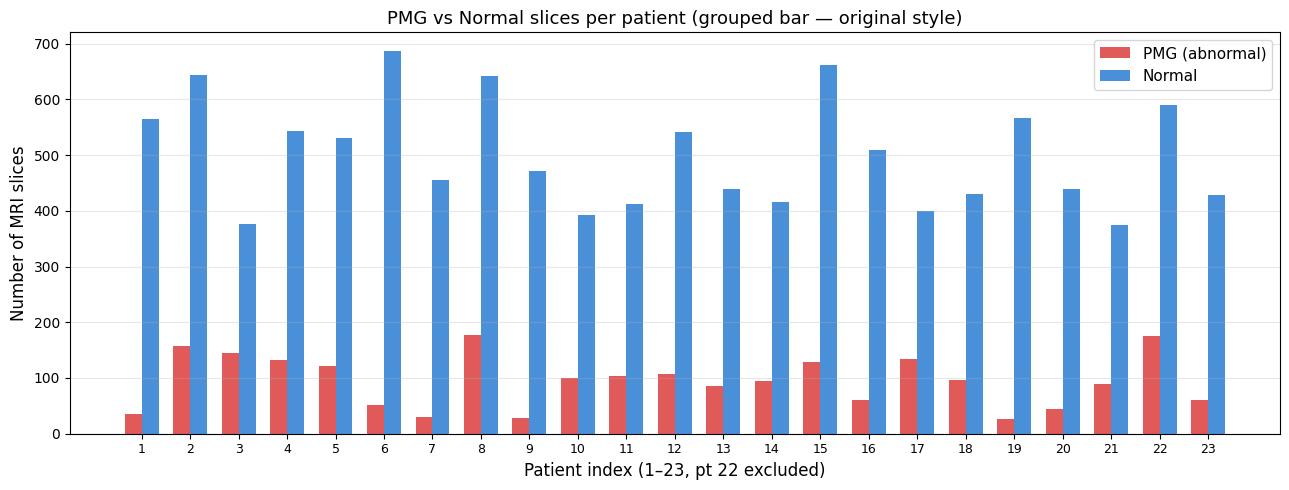

In [ ]:
# ── grouped bars 
N = len(df_stats_clean)
X = np.arange(N)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(X + 0.00, df_stats_clean['abnormal'].values, width=0.35,
       color='#e05a5a', label='PMG (abnormal)')
ax.bar(X + 0.35, df_stats_clean['normal'].values,   width=0.35,
       color='#4a90d9', label='Normal')

ax.set_xticks(X + 0.175)
ax.set_xticklabels(range(1, N + 1), fontsize=9)
ax.set_xlabel('Patient index (1–23, pt 22 excluded)', fontsize=12)
ax.set_ylabel('Number of MRI slices', fontsize=12)
ax.set_title('PMG vs Normal slices per patient (grouped bar — original style)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

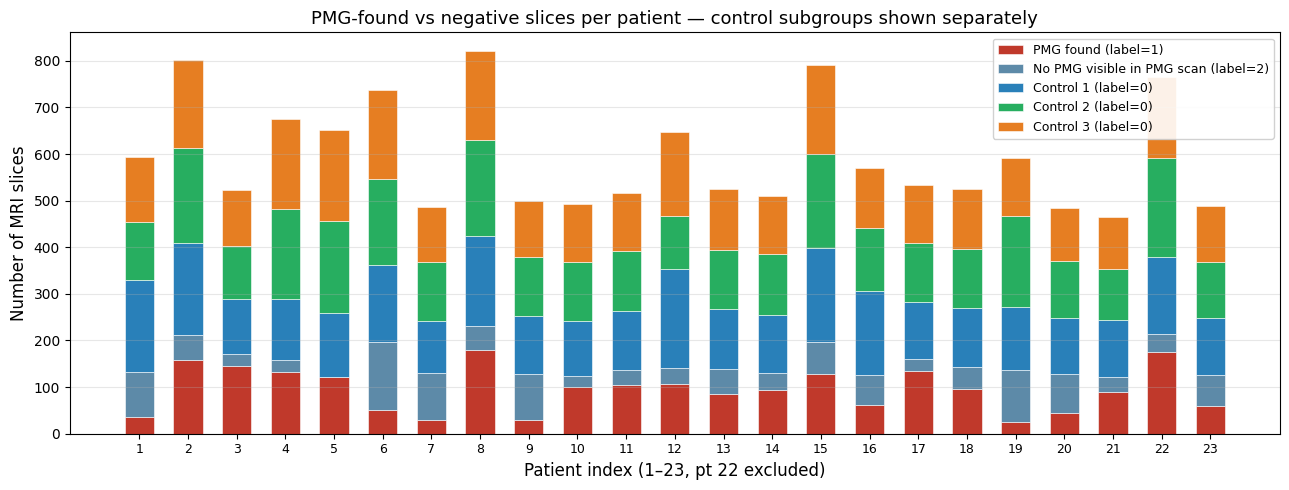

In [ ]:
# ── bar
STACK_COLORS = {
    'abnormal':   ('#C0392B', 'PMG found (label=1)'),          # crimson
    'normal_pmg': ('#5D8AA8', 'No PMG visible in PMG scan (label=2)'),  # steel blue
    'control1':   ('#2980B9', 'Control 1 (label=0)'),          # blue
    'control2':   ('#27AE60', 'Control 2 (label=0)'),          # green
    'control3':   ('#E67E22', 'Control 3 (label=0)'),          # orange
}

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(N)

for col, (color, label) in STACK_COLORS.items():
    vals = df_stats_clean[col].values
    ax.bar(X, vals, bottom=bottom, width=0.6,
           color=color, label=label,
           edgecolor='white', linewidth=0.4)
    bottom += vals

ax.set_xticks(X)
ax.set_xticklabels(range(1, N + 1), fontsize=9)
ax.set_xlabel('Patient index (1–23, pt 22 excluded)', fontsize=12)
ax.set_ylabel('Number of MRI slices', fontsize=12)
ax.set_title('PMG-found vs negative slices per patient — control subgroups shown separately', fontsize=13)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4  Combined PMG vs Normal slice counts

Aggregated view across all patients (excluding patient 22).  
The pie chart and summary bar give the global class balance.

Folder-level slice counts (all patients, all labels):
  PMG patient folder : 4,517
  Control folder     : 10,539
  Grand total        : 15,056

Within the PMG folder, per-slice label breakdown:
  label=1 (PMG-positive) : 2,256
  label=2 (normal)       : 1,386
  label=3 (uncertain)    : 875
  Total                  : 4,517


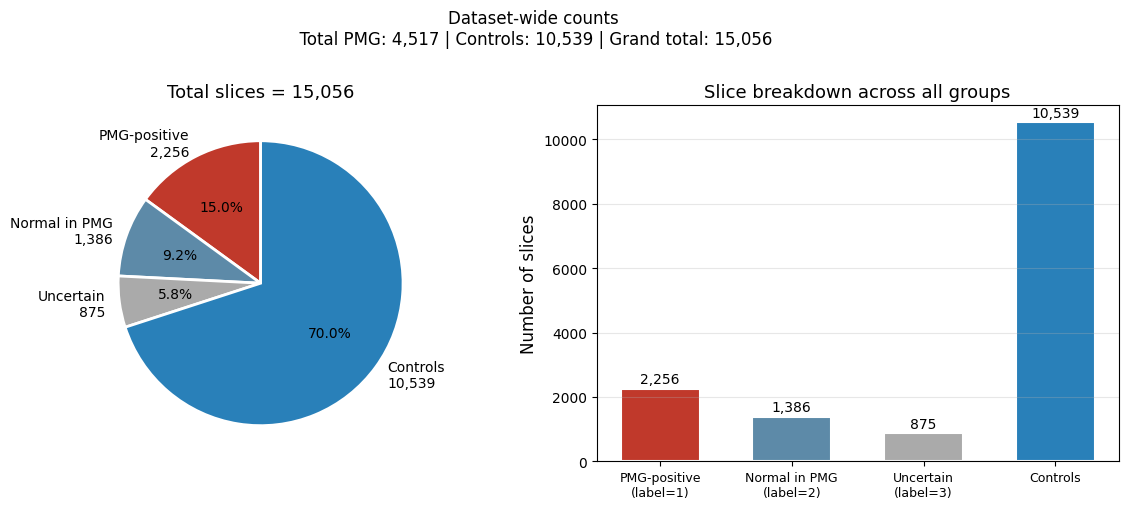

In [ ]:
# combined plot with pie + bar

total_pmg_folder  = (df_sizes['group'] == 'PMG').sum()
total_ctrl_folder = df_sizes['group'].str.startswith('control').sum()
grand_total       = total_pmg_folder + total_ctrl_folder

print('Folder-level slice counts (all patients, all labels):')
print(f'  PMG patient folder : {total_pmg_folder:,}')
print(f'  Control folder     : {total_ctrl_folder:,}')
print(f'  Grand total        : {grand_total:,}')
print()

# Reconstruct raw label counts including label=3
label_records_all = []
for patient in os.listdir(PMG_DIR):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    for fname in os.listdir(os.path.join(pt_path, sub)):
        if fname.lower().endswith('.jpg'):
            label_records_all.append(int(fname.split('.')[0].split('_')[-3]))

from collections import Counter
lc = Counter(label_records_all)
print('Within the PMG folder, per-slice label breakdown:')
print(f'  label=1 (PMG-positive) : {lc[1]:,}')
print(f'  label=2 (normal)       : {lc[2]:,}')
print(f'  label=3 (uncertain)    : {lc[3]:,}')
print(f'  Total                  : {sum(lc.values()):,}')

# ── Pie + bar 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie — folder-level split
axes[0].pie(
    [lc[1], lc[2], lc[3], total_ctrl_folder],
    labels=[f'PMG-positive\n{lc[1]:,}', f'Normal in PMG\n{lc[2]:,}', f'Uncertain\n{lc[3]:,}', f'Controls\n{total_ctrl_folder:,}'],
    colors=['#C0392B','#5D8AA8', '#AAAAAA', '#2980B9'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f'Total slices = {grand_total:,}', fontsize=13)

# Stacked bar — within PMG folder, show label breakdown
bars_data = {
    'PMG-positive\n(label=1)': (lc[1],  '#C0392B'),
    'Normal in PMG\n(label=2)': (lc[2], '#5D8AA8'),
    'Uncertain\n(label=3)':    (lc[3],  '#AAAAAA'),
    'Controls':         (total_ctrl_folder, '#2980B9'),
}
x_pos = list(range(len(bars_data)))
for i, (lbl, (val, color)) in enumerate(bars_data.items()):
    axes[1].bar(i, val, color=color, edgecolor='white', linewidth=1.5, width=0.6)
    axes[1].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bars_data.keys(), fontsize=9)
axes[1].set_ylabel('Number of slices', fontsize=12)
axes[1].set_title('Slice breakdown across all groups', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Dataset-wide counts\n  Total PMG: {total_pmg_folder:,} | Controls: {total_ctrl_folder:,} | Grand total: {grand_total:,} ',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

Folder-level slice counts (all patients, all labels):
  PMG patient folder : 4,517
  Control folder     : 10,539
  Grand total        : 15,056

Within the PMG folder, per-slice label breakdown:
  label=1 (PMG-positive) : 2,256
  label=2 (normal)       : 1,386
  Total                  : 4,517


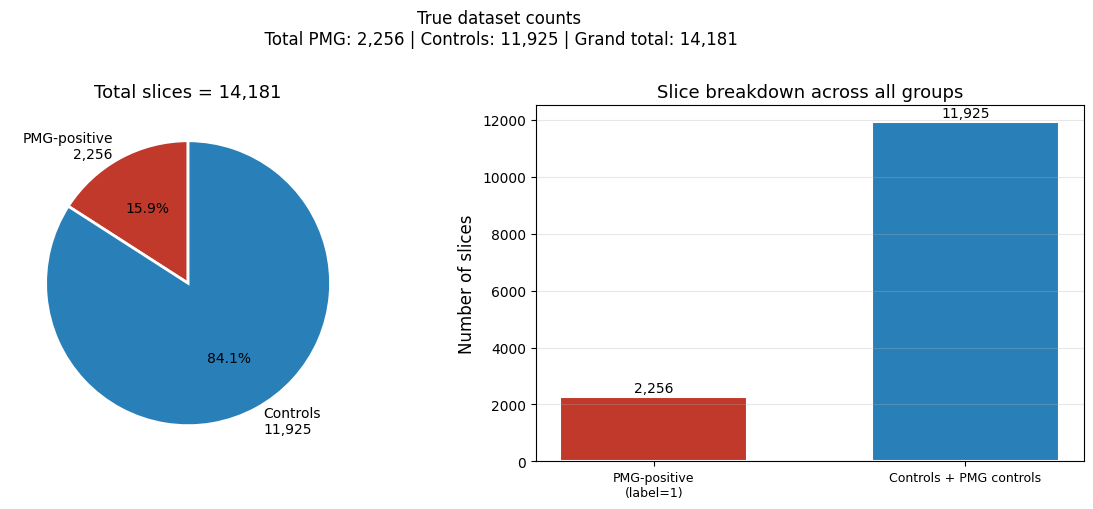

In [ ]:
# combined plot with pie + bar
total_pmg_folder  = (df_sizes['group'] == 'PMG').sum()
total_ctrl_folder = df_sizes['group'].str.startswith('control').sum()
grand_total       = total_pmg_folder + total_ctrl_folder

print('Folder-level slice counts (all patients, all labels):')
print(f'  PMG patient folder : {total_pmg_folder:,}')
print(f'  Control folder     : {total_ctrl_folder:,}')
print(f'  Grand total        : {grand_total:,}')
print()

# Reconstruct raw label counts including label=3
label_records_all = []
for patient in os.listdir(PMG_DIR):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    for fname in os.listdir(os.path.join(pt_path, sub)):
        if fname.lower().endswith('.jpg'):
            label_records_all.append(int(fname.split('.')[0].split('_')[-3]))

from collections import Counter
lc = Counter(label_records_all)
print('Within the PMG folder, per-slice label breakdown:')
print(f'  label=1 (PMG-positive) : {lc[1]:,}')
print(f'  label=2 (normal)       : {lc[2]:,}')
print(f'  Total                  : {sum(lc.values()):,}')

# ── Pie + bar d
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie — folder-level split
axes[0].pie(
    [lc[1], total_ctrl_folder+lc[2]],
    labels=[f'PMG-positive\n{lc[1]:,}', f'Controls\n{total_ctrl_folder+lc[2]:,}'],
    colors=['#C0392B', '#2980B9'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f'Total slices = {grand_total-lc[3]:,}', fontsize=13)

# Stacked bar — within PMG folder, show label breakdown
bars_data = {
    'PMG-positive\n(label=1)': (lc[1],  '#C0392B'),
    'Controls + PMG controls':         (total_ctrl_folder+lc[2], '#2980B9'),
}
x_pos = list(range(len(bars_data)))
for i, (lbl, (val, color)) in enumerate(bars_data.items()):
    axes[1].bar(i, val, color=color, edgecolor='white', linewidth=1.5, width=0.6)
    axes[1].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bars_data.keys(), fontsize=9)
axes[1].set_ylabel('Number of slices', fontsize=12)
axes[1].set_title('Slice breakdown across all groups', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'True dataset counts\n  Total PMG: {lc[1]:,} | Controls: {total_ctrl_folder+lc[2]:,} | Grand total: {grand_total-lc[3]:,} ',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

---
## Summary

### Label convention

| Label | Folder | Meaning | Role in classifier |
|---|---|---|---|
| `0` | Controls | Healthy brain slice | Negative class |
| `1` | PMG cases | **PMG found** — this slice shows polymicrogyria | Positive class |
| `2` | PMG cases | **No PMG visible** — PMG patient scan, this slice looks normal | Negative class |
| `3` | PMG cases | **Uncertain / excluded** — ambiguous annotation | Removed entirely |

### Key observations
- All PMG-patient slices are at **1508 × 1727 px**; controls vary (260×320 → 512×512) — a potential confound.
- The overall class imbalance (negative:positive) is roughly **~8:1**.
- Label=3 (uncertain) accounts for ~19% of PMG-patient slices and could represent boundary/transition zones.

---
## 5  Preprocessing comparison — Before vs After

For 4 PMG and 4 control patients we pick a representative middle slice and display it across all preprocessing presets side by side.

**Columns:** Original → `no_filter` (norm + CLAHE only) → `minimal` (gentle blur/edges) → `light` (moderate) → `default` (full pipeline matching Guha & Bhandage 2025)

This lets us judge visually how aggressively each preset alters the image and whether any artefacts are introduced.

PMG patients collected : ['2']
Control patients       : ['2']


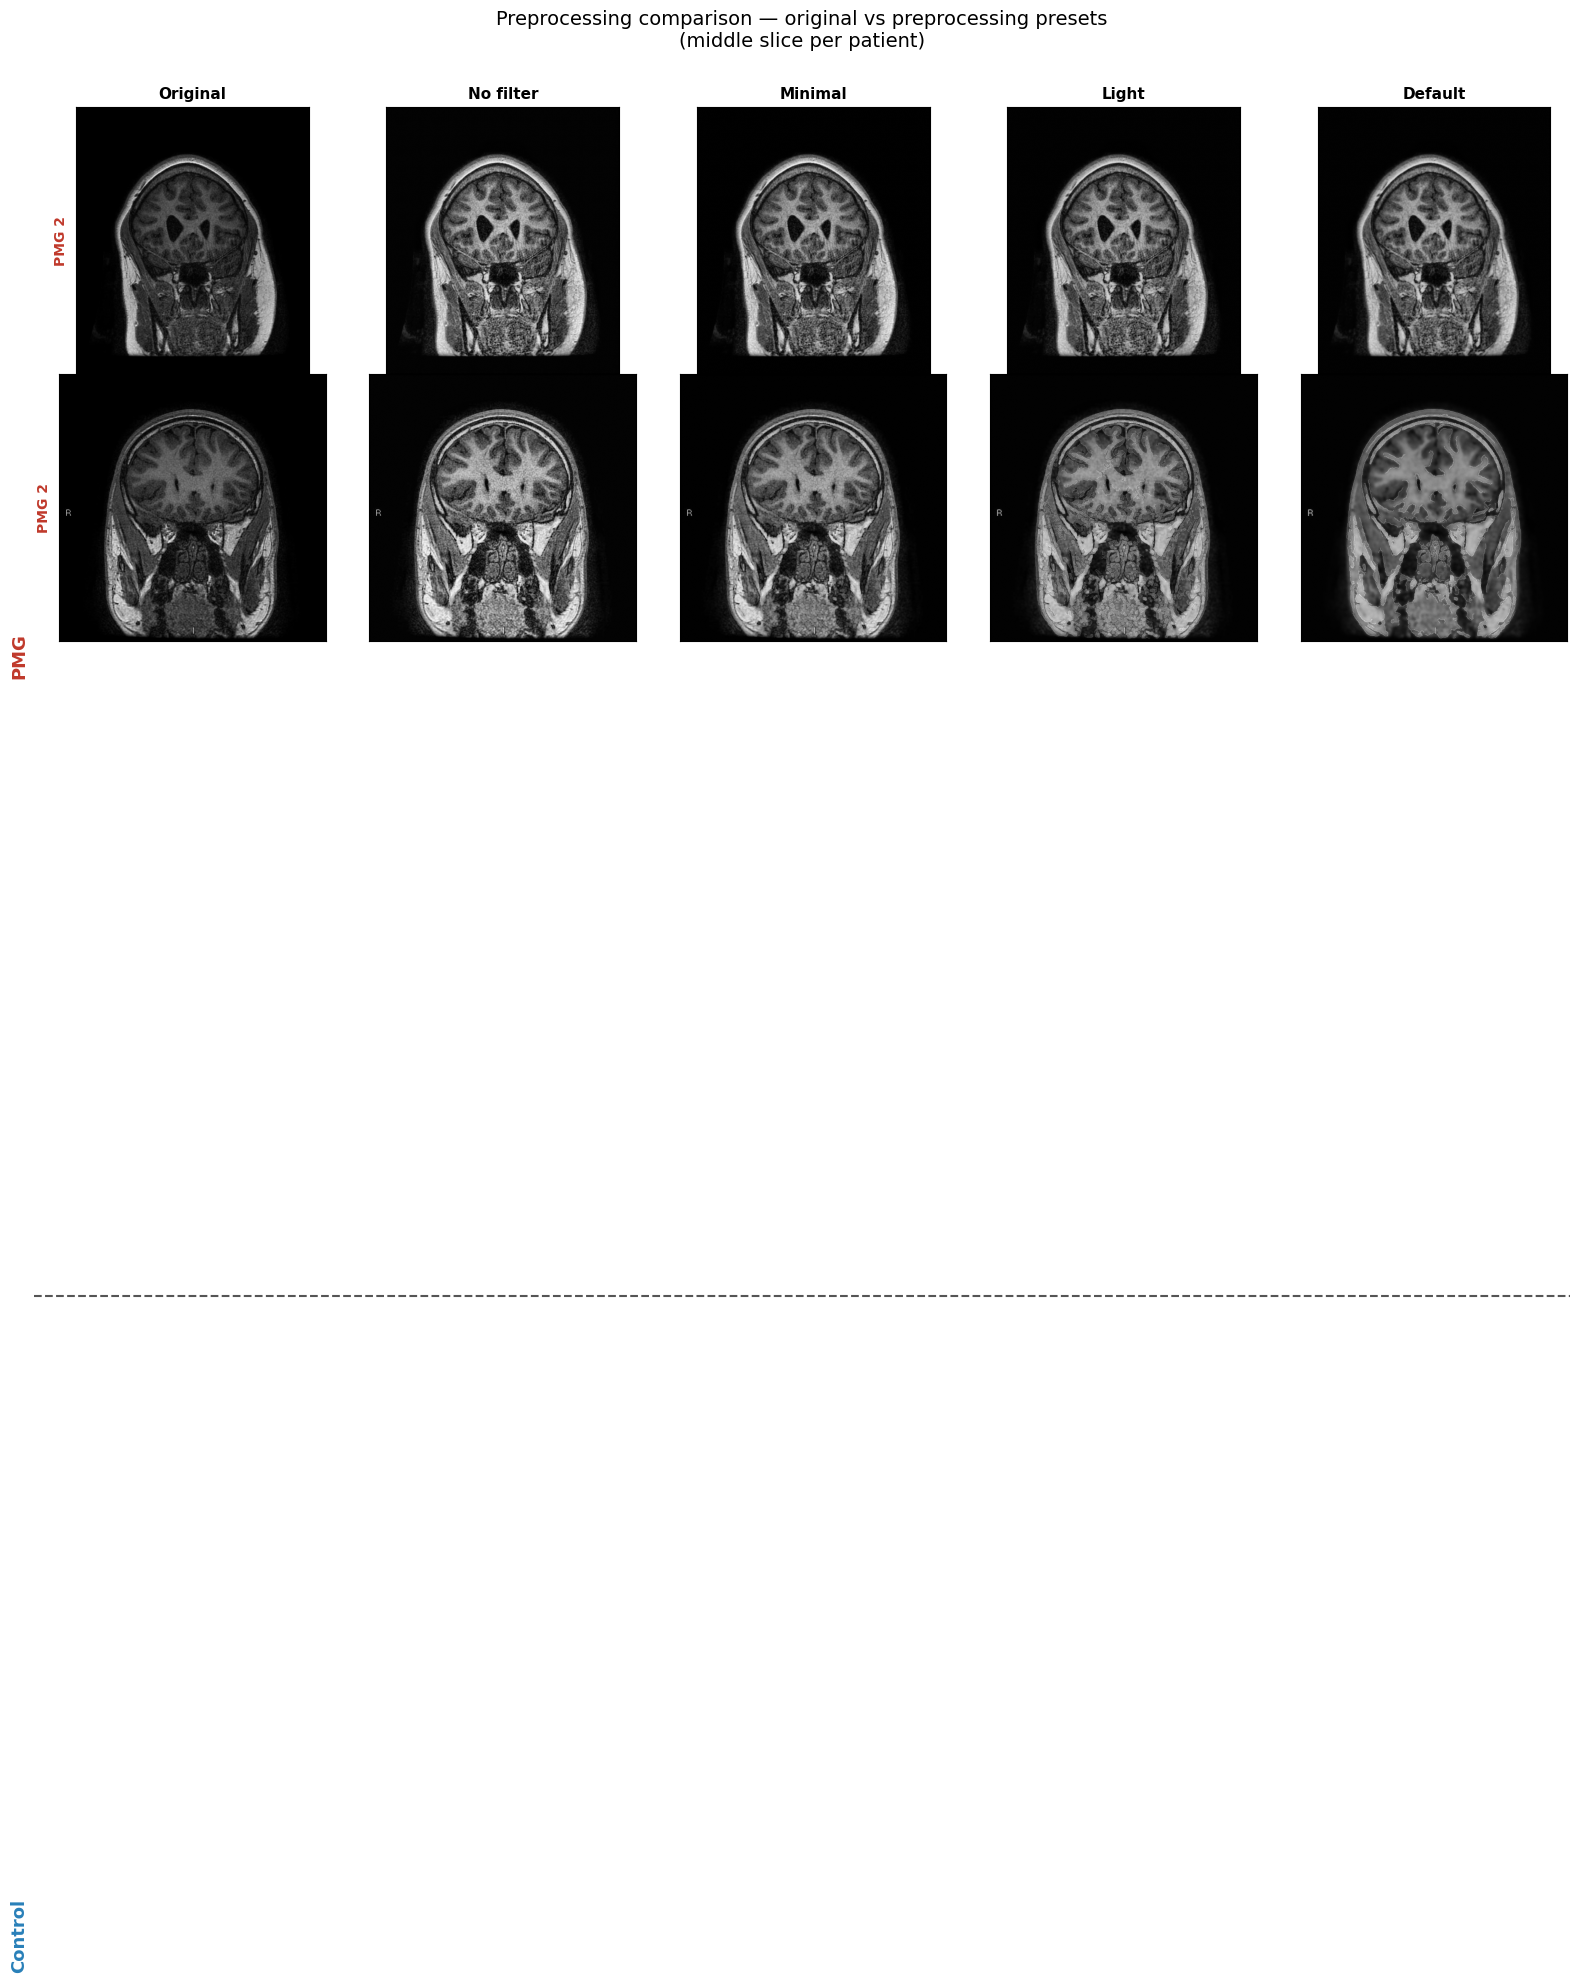

In [ ]:
import glob as _glob
from pathlib import Path

# ── Paths to raw (original) data
RAW_BASE     = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'data', 'PPMR'))
RAW_PMG_DIR  = os.path.join(RAW_BASE, 'PMGstudycaseslabelled')
RAW_CTRL_DIR = os.path.join(RAW_BASE, 'PMGControlsEditedDec2021')

PRESETS     = ['no_filter', 'minimal', 'light', 'default']
COL_TITLES  = ['Original', 'No filter', 'Minimal', 'Light', 'Default']
N_PATIENTS  = 4   


# ── Helpers

def get_middle_slice(pt_dir: str, preset: str) -> str | None:
    """Return the middle slice path (sorted) for a given patient dir and preset."""
    slices = natsorted(
        _glob.glob(os.path.join(pt_dir, '**', f'*_preprocessed_{preset}.jpg'), recursive=True)
    )
    return slices[len(slices) // 2] if slices else None


def all_variants(preprocessed_path: str) -> dict:
    """Given one preprocessed path, return {preset: Path, 'original': Path | None}."""
    p = Path(preprocessed_path)
    base_stem = p.stem.rsplit('_preprocessed_', 1)[0]   # strip _preprocessed_<preset>
    variants = {preset: p.parent / f'{base_stem}_preprocessed_{preset}.jpg'
                for preset in PRESETS}
    # find original in raw dirs
    raw_hits = (
        _glob.glob(os.path.join(RAW_PMG_DIR,  '**', f'{base_stem}.jpg'), recursive=True) +
        _glob.glob(os.path.join(RAW_CTRL_DIR, '**', f'{base_stem}.jpg'), recursive=True)
    )
    variants['original'] = Path(raw_hits[0]) if raw_hits else None
    return variants


# ── Collect one representative slice per patient

def collect_patients(proc_dir: str, n: int) -> list[dict]:
    """Return list of variant dicts for the first n patients in proc_dir."""
    rows = []
    for pt in natsorted(os.listdir(proc_dir))[:n]:
        pt_path = os.path.join(proc_dir, pt)
        ref_path = get_middle_slice(pt_path, preset='default')
        if ref_path is None:
            continue
        v = all_variants(ref_path)
        v['patient_id'] = pt
        rows.append(v)
    return rows

pmg_rows  = collect_patients(PMG_DIR,  N_PATIENTS)
ctrl_rows = collect_patients(CTRL_DIR, N_PATIENTS)

print(f'PMG patients collected : {[r["patient_id"] for r in pmg_rows]}')
print(f'Control patients       : {[r["patient_id"] for r in ctrl_rows]}')


# ── Plot

N_COLS   = len(COL_TITLES)          # 5
all_rows = pmg_rows + ctrl_rows      # 8 rows total
N_ROWS   = len(all_rows)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3.2, N_ROWS * 3.2))

COL_KEYS  = ['original'] + PRESETS  # column order matches COL_TITLES

PMG_COLOR  = '#C0392B'
CTRL_COLOR = '#2980B9'

for row_idx, row in enumerate(all_rows):
    is_pmg    = row_idx < N_PATIENTS
    pt_label  = f"{'PMG' if is_pmg else 'Ctrl'} {row['patient_id']}"
    row_color = PMG_COLOR if is_pmg else CTRL_COLOR

    for col_idx, (key, title) in enumerate(zip(COL_KEYS, COL_TITLES)):
        ax = axes[row_idx, col_idx]
        img_path = row.get(key)

        if img_path is not None and Path(img_path).exists():
            img = Image.open(img_path).convert('L')
            ax.imshow(img, cmap='gray', aspect='equal')
        else:
            ax.text(0.5, 0.5, 'not found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')

        ax.set_xticks([])
        ax.set_yticks([])

        # Column headers on first row
        if row_idx == 0:
            ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

        # Row labels on first column
        if col_idx == 0:
            ax.set_ylabel(pt_label, fontsize=10, color=row_color,
                          fontweight='bold', labelpad=6)

# Horizontal divider between PMG and Control blocks
fig.add_artist(
    plt.Line2D(
        [0.02, 0.98],
        [1 - N_PATIENTS / N_ROWS, 1 - N_PATIENTS / N_ROWS],
        transform=fig.transFigure, color='#555555',
        linewidth=1.5, linestyle='--',
    )
)

# Group labels
fig.text(0.005, 1 - (N_PATIENTS / 2) / N_ROWS,
         'PMG', va='center', ha='left', fontsize=13,
         fontweight='bold', color=PMG_COLOR, rotation=90)
fig.text(0.005, 1 - (N_PATIENTS + N_PATIENTS / 2) / N_ROWS,
         'Control', va='center', ha='left', fontsize=13,
         fontweight='bold', color=CTRL_COLOR, rotation=90)

fig.suptitle('Preprocessing comparison — original vs preprocessing presets\n(middle slice per patient)',
             fontsize=14, y=1.01)
plt.tight_layout(h_pad=0.4, w_pad=0.3)
plt.show()